# A worked example: from genotypes to local ancestry, panel QC, and hidden sources

This notebook follows one analysis end to end, using the pieces a real study touches in order. We start from **genotypes** (a VCF / VCF-Zarr — simulated here so we have ground truth), build a tree sequence two different ways, **paint** local ancestry from each and compare them, then turn the same machinery on two questions every admixture study eventually asks:

1. **From genotypes to a tree sequence** — `tspaint.io.tsinfer` / `tspaint.io.singer` take a VCF, a VCF-Zarr, or a tree sequence through one unified interface.
2. **Paint and compare** — `tspaint.paint` on a fast **tsinfer** point-estimate ARG vs. a Bayesian **SINGER** posterior ARG; where they agree, where SINGER's posterior is more robust, and the **calibrated uncertainty band** that averaging SINGER samples buys you.
3. **Reference QC** — `tspaint.reference_qc` audits the reference panel itself for admixed / mislabelled individuals.
4. **Hidden (non-reference) admixture** — `tspaint.detect_ghost` flags tracts from a source that is *not in the panel*, and `tspaint.detect_archaic` does it with **no reference at all**.

Each capability needs a slightly different cohort, so we simulate a fresh one at each step — but read it as one analyst's progression: *get data → paint it → check whether you can trust your references → check whether something unsampled is hiding in the admixture.*

Everything is simulated with [`msprime`](https://tskit.dev/msprime/docs/stable/) so a **census event** records the true local ancestry of every haplotype, which we score against.

## Setup

A few imports and small helpers: `pops` maps sample nodes to their (simulated) source population, `write_vcz` lays out a minimal VCF-Zarr the way `bio2zarr`'s `vcf2zarr` would, and two plotting helpers draw a painted posterior against the shaded truth.

In [1]:
import os, tempfile, warnings
warnings.simplefilter("ignore")          # quiet tsinfer/Numba provenance chatter
import numpy as np
import matplotlib.pyplot as plt
import tspaint
from tspaint import io
from tspaint.validate import map_truth, balanced_accuracy, mean_confidence, per_base_accuracy
from vscodenb import set_vscode_theme, vscode_theme
set_vscode_theme()

WORK = tempfile.mkdtemp(prefix="tspaint_showcase_")


def pops(ts):
    '''sample-node -> source name, and a {name: pop_id} lookup.'''
    npop = ts.tables.nodes.population
    name = {p: ts.population(p).metadata.get("name", str(p)) for p in range(ts.num_populations)}
    pid = {n: p for p, n in name.items()}
    samples_of = lambda nm: [int(s) for s in ts.samples() if npop[s] == pid[nm]]
    return name, pid, samples_of


def write_vcz(ts, path):
    '''Write a minimal VCF-Zarr (vcz) store from a mutated ts (stand-in for vcf2zarr output).'''
    import zarr
    G = ts.genotype_matrix()                       # (sites, samples), biallelic 0/1
    V, N = G.shape
    root = zarr.open(path, mode="w")
    def arr(nm, data, dims):
        root[nm] = data
        root[nm].attrs["_ARRAY_DIMENSIONS"] = dims
    arr("variant_position", np.asarray(ts.tables.sites.position).astype("i8"), ["variants"])
    arr("call_genotype", G[:, :, None].astype("i1"), ["variants", "samples", "ploidy"])
    arr("variant_allele", np.array([["0", "1"]] * V), ["variants", "alleles"])
    arr("variant_contig", np.zeros(V, "i4"), ["variants"])
    arr("contig_id", np.array(["1"]), ["contigs"])
    arr("sample_id", np.array([f"n{i}" for i in range(N)]), ["samples"])
    arr("variant_ancestral_allele", np.array(["0"] * V), ["variants"])
    return path


def track_xy(track, state):
    '''Step coordinates (x, P(state)) for a list of soft Segments.'''
    xs, ys = [], []
    for seg in track:
        xs += [seg.left, seg.right]
        ys += [float(seg.posterior[state])] * 2
    return np.asarray(xs), np.asarray(ys)


def plot_painting(ax, tracks, truth_segs, L, title, state=1):
    '''Shade the true `state` (B) tracts; overlay each painter's P(state=B).'''
    for (l, r, st) in truth_segs:
        if st == state:
            ax.axvspan(l / 1e3, r / 1e3, color="0.6", lw=0, alpha=0.5, zorder=0)
    for label, track in tracks.items():
        xs, ys = track_xy(track, state)
        ax.plot(xs / 1e3, ys, lw=1.6, label=label, alpha=0.6)
    ax.set(ylim=(-0.02, 1.02), xlim=(0, L / 1e3), title=title,
           xlabel="position (kb)", ylabel="P(ancestry = B)")
    ax.axhline(0.5, color="0.6", lw=0.6, ls=":")
    ax.legend(loc="center left")


## 1. From genotypes to a tree sequence

Real input is genotypes — a phased **VCF** or, at scale, a chunked **VCF-Zarr**. `tspaint` never asks you to build the tree sequence by hand: the two inference front ends take any of the three sources through one interface (`source` = a tree sequence, a `.vcf[.gz]`, or a `.zarr` store) and hand back a tspaint-ready tree sequence.

Here we *simulate* an admixed cohort so we know the truth — 8 admixed individuals (the queries) plus pure `A` and `B` reference panels — overlay mutations, and write it out as a VCF (and a VCF-Zarr) exactly as if it had come off a sequencing pipeline.

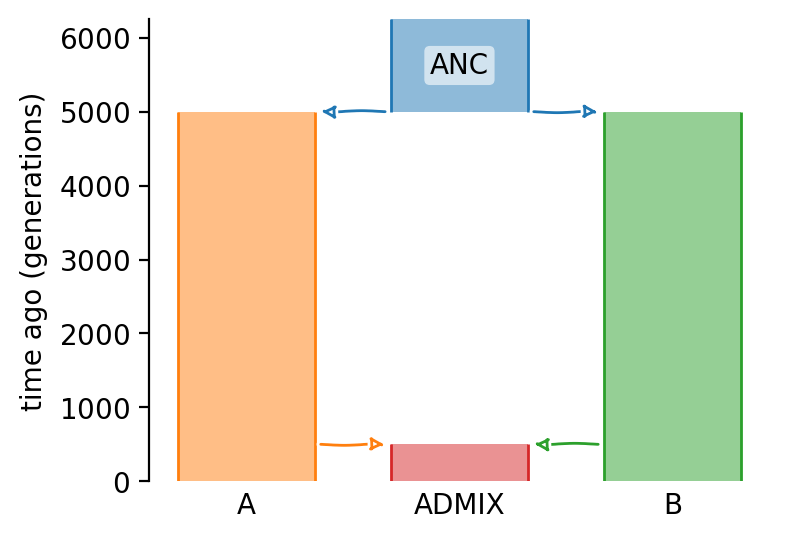

In [2]:
from tspaint.sim import SOURCE_A, SOURCE_B, ADMIXED, ANCESTRAL
import demesdraw
import msprime

Ne=1000
T_admix=500
T_split=5000
f_A=0.5
sequence_length = 2e6
recombination_rate = 1e-8
mutation_rate = 1e-8
ploidy = 2
random_seed = 1
infer = True

n_admix = 8
n_ref = 8

demography = msprime.Demography()
demography.add_population(name=SOURCE_A, initial_size=Ne)
demography.add_population(name=SOURCE_B, initial_size=Ne)
demography.add_population(name=ADMIXED, initial_size=Ne)
demography.add_population(name=ANCESTRAL, initial_size=Ne)
# Admixed pop forms (backward in time) as a mixture of the two sources.
demography.add_admixture(time=T_admix, derived=ADMIXED,
                ancestral=[SOURCE_A, SOURCE_B], proportions=[f_A, 1.0 - f_A])
# Census after the pulse: every lineage is now in A or B; census nodes label
# each lineage's source per genomic segment (the local-ancestry truth).
demography.add_census(time=T_admix + 1)
# Sources coalesce into a common ancestor deeper in time.
demography.add_population_split(time=T_split, derived=[SOURCE_A, SOURCE_B],
                        ancestral=ANCESTRAL)
graph = msprime.Demography.to_demes(demography)
with vscode_theme(style='ticks'):
    fig, ax = plt.subplots(figsize=(4, 3))
    demesdraw.tubes(graph, ax=ax, seed=1)

In [3]:
# Simulate a deliberately data-sparse cohort: a moderate-age pulse on a short region, so the
# point-estimate ARG is imperfect and there is something for a better ARG to improve on.

# sequence_length = 7e4
# ts_true = tspaint.simulate_admixture(n_admix=8, n_ref=8, sequence_length=sequence_length,
#                                      recombination_rate=1e-8, random_seed=1,
#                                      Ne=1000, T_admix=500, T_split=5000, f_A=0.5)
ts_true = msprime.sim_ancestry(
        samples={ADMIXED: n_admix, SOURCE_A: n_ref, SOURCE_B: n_ref},
        demography=demography,
        sequence_length=sequence_length,
        recombination_rate=recombination_rate,
        ploidy=ploidy,
        random_seed=random_seed,
    )
ts_true = io.add_mutations(ts_true, rate=5e-8, random_seed=1)

name, pid, samples_of = pops(ts_true)
queries = samples_of("ADMIX")
labels  = {s: 0 for s in samples_of("A")}
labels.update({s: 1 for s in samples_of("B")})
print(f"{ts_true.num_samples} haplotypes, {ts_true.num_sites} sites; "
      f"{len(queries)} query haplotypes, {len(labels)} labelled references (A=0, B=1)")

# Write the genotypes as a VCF and as a VCF-Zarr (what you would actually start from).
vcf = os.path.join(WORK, "cohort.vcf"); io.write_haploid_vcf(ts_true, vcf)
vcz = write_vcz(ts_true, os.path.join(WORK, "cohort.vcz"))

# One interface, three source kinds -- dispatched automatically:
from tspaint.io_genotypes import source_kind
print("source_kind:", {k: source_kind(v) for k, v in
                        {"tree sequence": ts_true, "VCF": vcf, "VCF-Zarr": vcz}.items()})

# Ground truth (from the census event) for scoring later.
truth, _ = tspaint.local_ancestry_truth(ts_true)
state_of_pop = {pid["A"]: 0, pid["B"]: 1}
truth_states = map_truth({q: truth[q] for q in queries}, state_of_pop)


48 haplotypes, 4051 sites; 16 query haplotypes, 32 labelled references (A=0, B=1)
source_kind: {'tree sequence': 'ts', 'VCF': 'vcf', 'VCF-Zarr': 'zarr'}


## Tree sequences with tsinfer and SINGER

`tspaint.io.tsinfer` builds a single best-guess ARG; `tspaint.io.singer` runs SINGER's MCMC and returns a **list of posterior ARG samples**. Both accept the same `source` — we hand both the VCF we just wrote. (`io.tsinfer(vcz)` would read the Zarr chunked via `tsinfer.VariantData`, the scalable path for whole-genome data.)

We then `paint` each. On an inferred ARG we enable `smooth=True` (the genome-axis BP smoother) to suppress switches that are artifacts of tree-inference noise.

Produce a single TreeSequence using `tsinfer`:

In [4]:
ts_tsinfer = io.tsinfer(vcf)
ts_tsinfer

Produce a TreeSequence using `SINGER`:

In [5]:
ts_singer = io.singer(
    vcf, 
    Ne=1000, mutation_rate=5e-8, recombination_rate=1e-8,
    seed=42, sequence_length=sequence_length,
    )
ts_singer

## Painting / Local ancestry inference

Paint sequences using `tsinfer` tree sequence:

In [6]:
# Paint the queries from each (smooth=True: these are inferred ARGs).
paint_tsinfer  = tspaint.paint(ts_tsinfer, labels, queries, smooth=True)

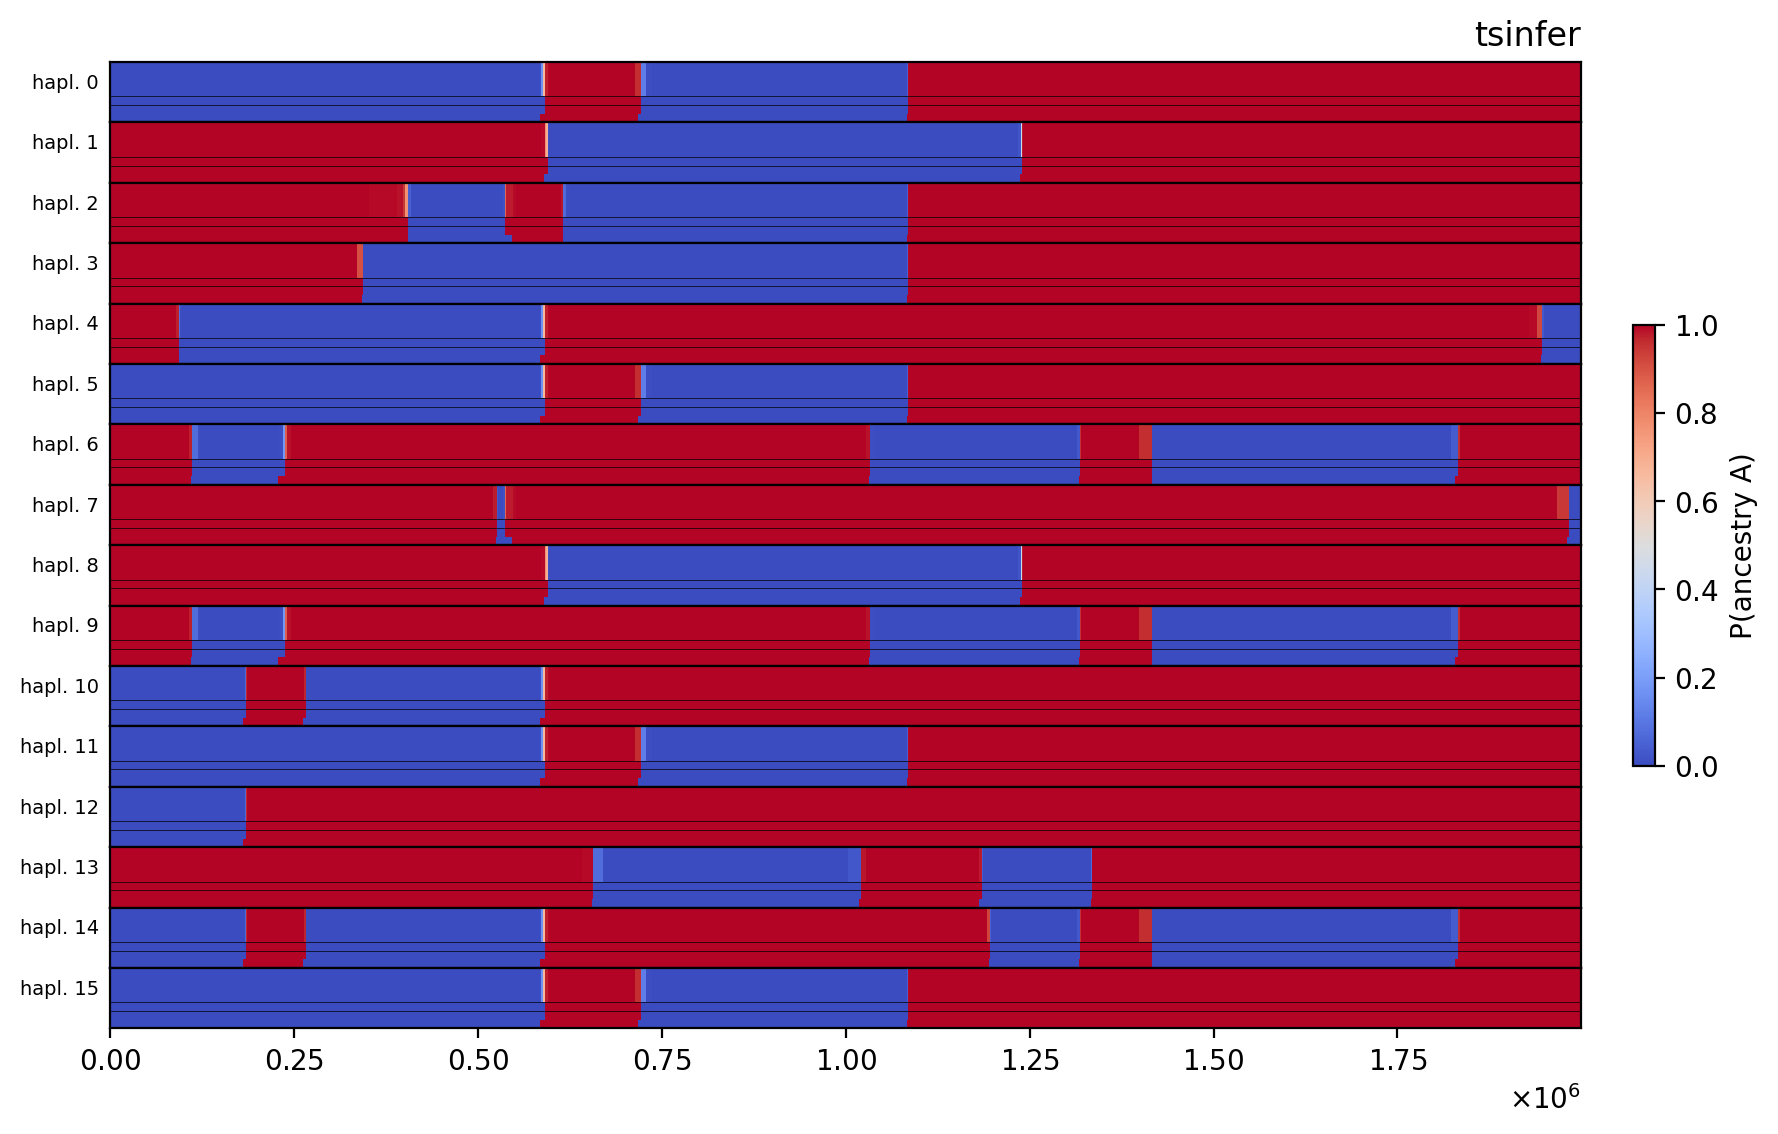

In [7]:
paint_tsinfer.plot(truth=truth, title='tsinfer',
            #    cmap='PiYG',
                           #colors = ["#C25F3D", "#F4F3ED", "#2A79D7"]
                           )

Paint sequences using `SINGER` tree sequence:

In [8]:
paint_singer = tspaint.paint(ts_singer, labels, queries, smooth=True)

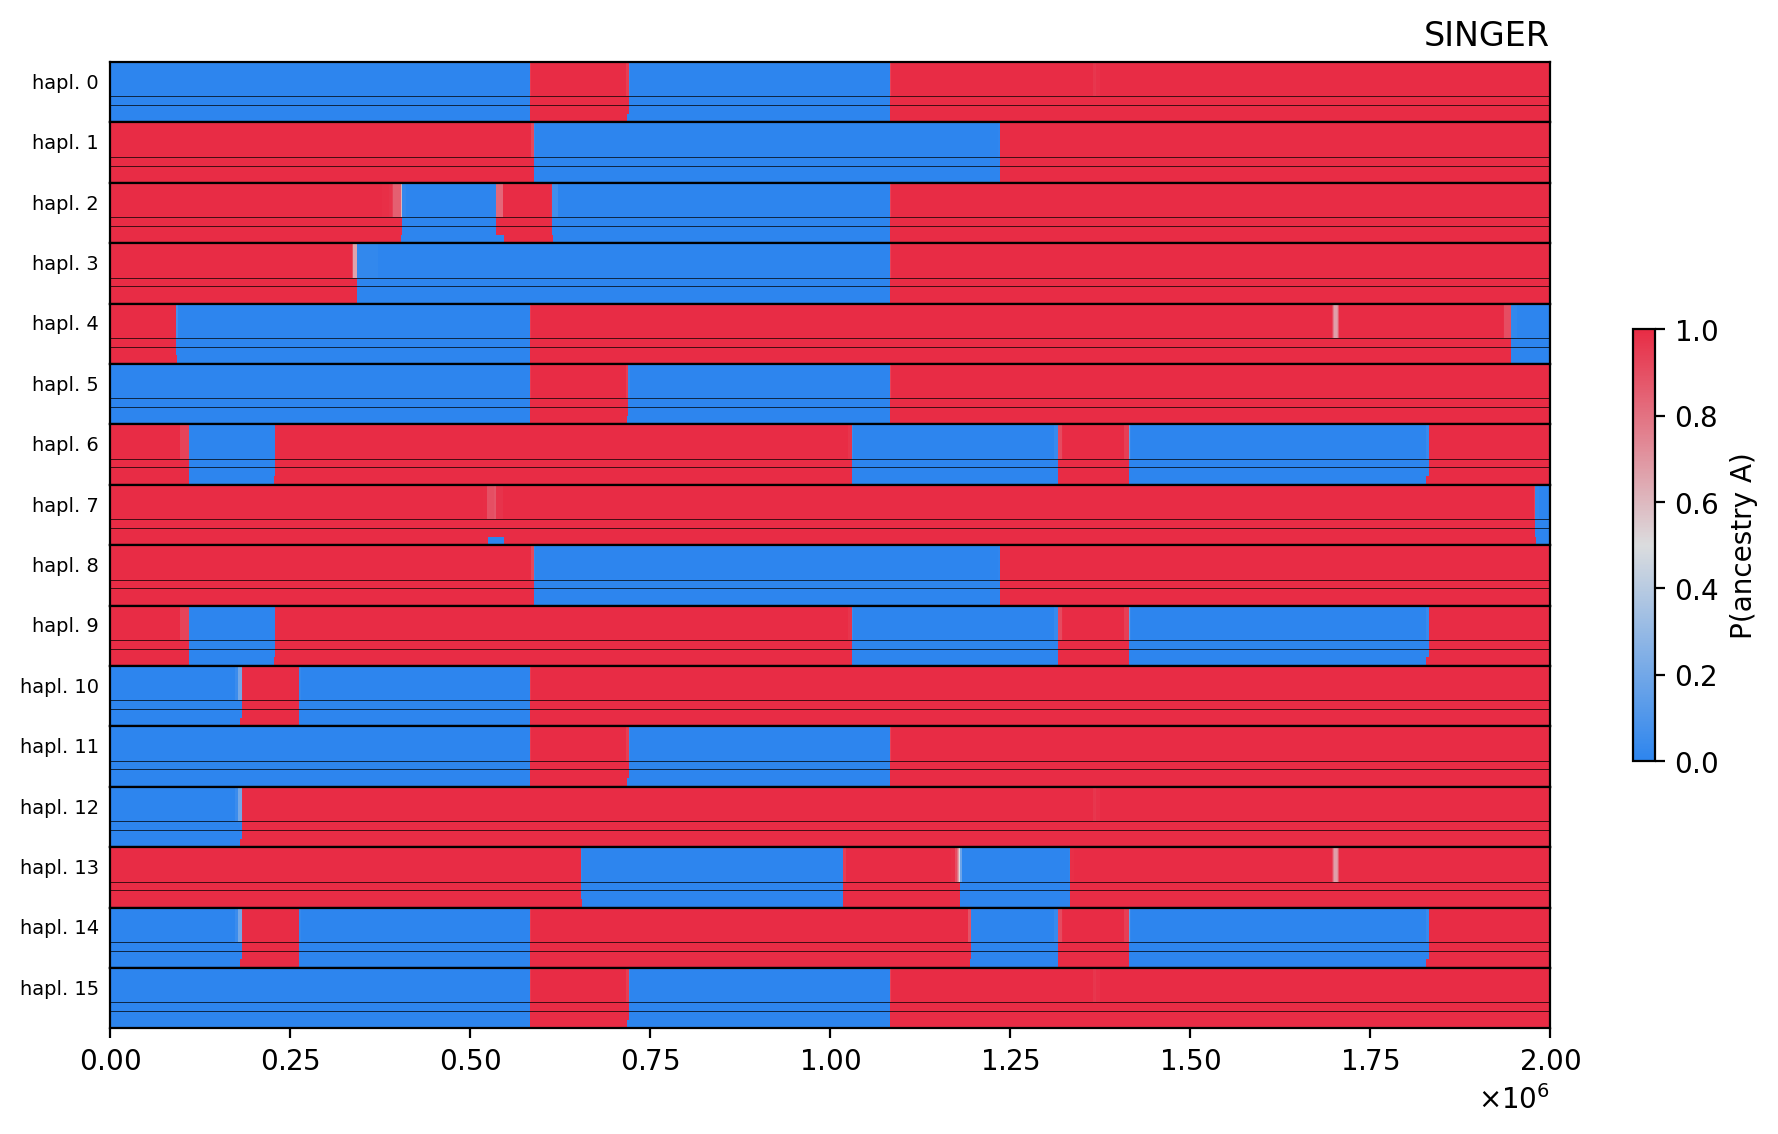

In [9]:
paint_singer.plot(truth=truth, title='SINGER', colors=[ '#2D85EE', '#DBDCDE', "#E82C45"])

In [10]:
for tag, p in [("tsinfer (point estimate)", paint_tsinfer), ("SINGER (one posterior sample)", paint_singer)]:
    bal  = balanced_accuracy(p.posteriors, truth_states, samples=queries)
    conf = mean_confidence(p.posteriors, samples=queries)
    print(f"{tag:32s}  balanced acc {bal:.3f}   mean confidence {conf:.3f}")

tsinfer (point estimate)          balanced acc 0.994   mean confidence 0.998
SINGER (one posterior sample)     balanced acc 0.997   mean confidence 0.998


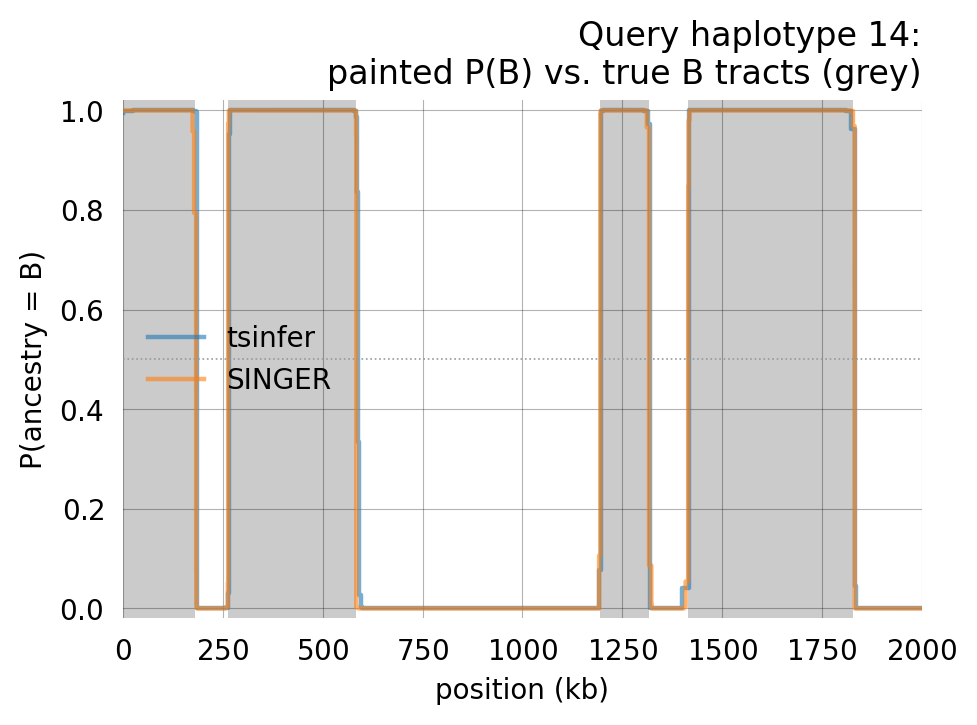

In [11]:
# show the most ancestry-balanced query -- a real A->B switch is the interesting case to look at
bfrac = lambda segs: sum(r - l for l, r, st in segs if st == 1) / sum(r - l for l, r, _ in segs)
q = max(queries, key=lambda x: min(bfrac(truth_states[x]), 1 - bfrac(truth_states[x])))
fig, ax = plt.subplots()
plot_painting(ax, {"tsinfer": paint_tsinfer.posteriors[q], "SINGER": paint_singer.posteriors[q]},
              truth_states[q], sequence_length, f"Query haplotype {q}:\npainted P(B) vs. true B tracts (grey)")
plt.tight_layout(); plt.show()


## Calibrated uncertainty band using SINGER's posterior

A single ARG cannot tell you how much to trust itself. Pass the **whole ensemble** to `paint` — it fits one pooled `(Q, π, w)`, paints every member, and **averages** the per-position posteriors, marginalising *which ARG* (the binding uncertainty on real data). The returned posteriors are `MergedSegment`s carrying the ensemble mean **and** a `posterior_std`ARG-uncertainty band (the `tspaint.ensemble.merge_posterior_tables` machinery, now in one call).


In [12]:
ts_singer_posterior = io.singer(vcf, Ne=1000, mutation_rate=5e-8, recombination_rate=1e-8,
                     n_samples=24, thin=2, burn_in=2, seed=42, sequence_length=sequence_length)

In [13]:
# paint() takes the whole ensemble directly: one pooled fit, paint each member, then average
# the per-position posteriors into MergedSegments (the mean painting + a posterior_std band).
paint_singer_posterior = tspaint.paint(ts_singer_posterior, labels, queries)
print(f"merged over {len(ts_singer_posterior)} SINGER ARGs:  balanced acc "
      f"{balanced_accuracy(paint_singer_posterior.posteriors, truth_states, samples=queries):.3f}   "
      f"mean confidence {mean_confidence(paint_singer_posterior.posteriors, samples=queries):.3f}")

merged over 22 SINGER ARGs:  balanced acc 0.996   mean confidence 0.898


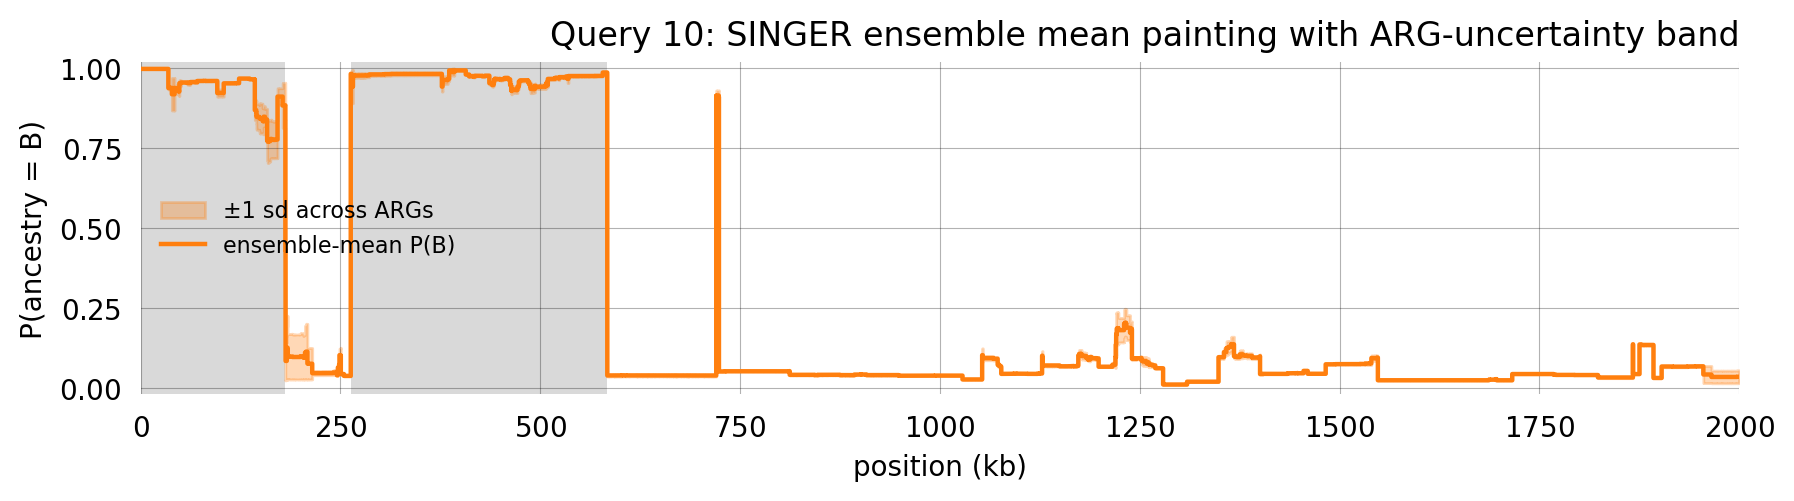

In [14]:
# Plot the mean painting +/- 1 sd across the ensemble for the query whose ARGs disagree most.
qb = max(queries, key=lambda s: max((sg.posterior_std[1] for sg in paint_singer_posterior.posteriors[s]), default=0.0))
seg = paint_singer_posterior.posteriors[qb]
xs = np.array([x for s in seg for x in (s.left, s.right)]) / 1e3
mu = np.array([s.posterior[1] for s in seg for _ in (0, 1)])
sd = np.array([s.posterior_std[1] for s in seg for _ in (0, 1)])
fig, ax = plt.subplots(figsize=(9, 2.6))
for (l, r, st) in truth_states[qb]:
    if st == 1: ax.axvspan(l / 1e3, r / 1e3, color="0.85", lw=0)
ax.fill_between(xs, np.clip(mu - sd, 0, 1), np.clip(mu + sd, 0, 1),
                color="C1", alpha=0.30, label="±1 sd across ARGs")
ax.plot(xs, mu, color="C1", lw=1.6, label="ensemble-mean P(B)")
ax.set(ylim=(-0.02, 1.02), xlim=(0, sequence_length / 1e3),
       title=f"Query {qb}: SINGER ensemble mean painting with ARG-uncertainty band",
       xlabel="position (kb)", ylabel="P(ancestry = B)")
ax.legend(loc="center left", fontsize=8, framealpha=0.9)
plt.tight_layout(); plt.show()

The band widens where the posterior ARGs disagree (shown here for the query with the most disagreement) and collapses where they concur — calibrated honesty a single ARG (or an overconfident segment method) does not provide. Averaging buys *calibration* rather than raw accuracy: the merged painting's mean confidence sits below a single sample's, and on some seeds averaging-then-argmax even dilutes a confidently-correct call. The number of SINGER samples is therefore a knob you spend on **uncertainty quantification**, not on accuracy.

> **Honest caveat.** Both methods are bounded by the genealogy, not by their own cleverness. On an unlucky region where the admixed haplotypes coalesce among themselves before the pulse, the query↔reference link is severed and *both* paintings fall to ~0.5 — the ancestry simply is not recoverable there (CLAUDE.md §9). The painting's job is to report that as `P ≈ 0.5`, not to guess.

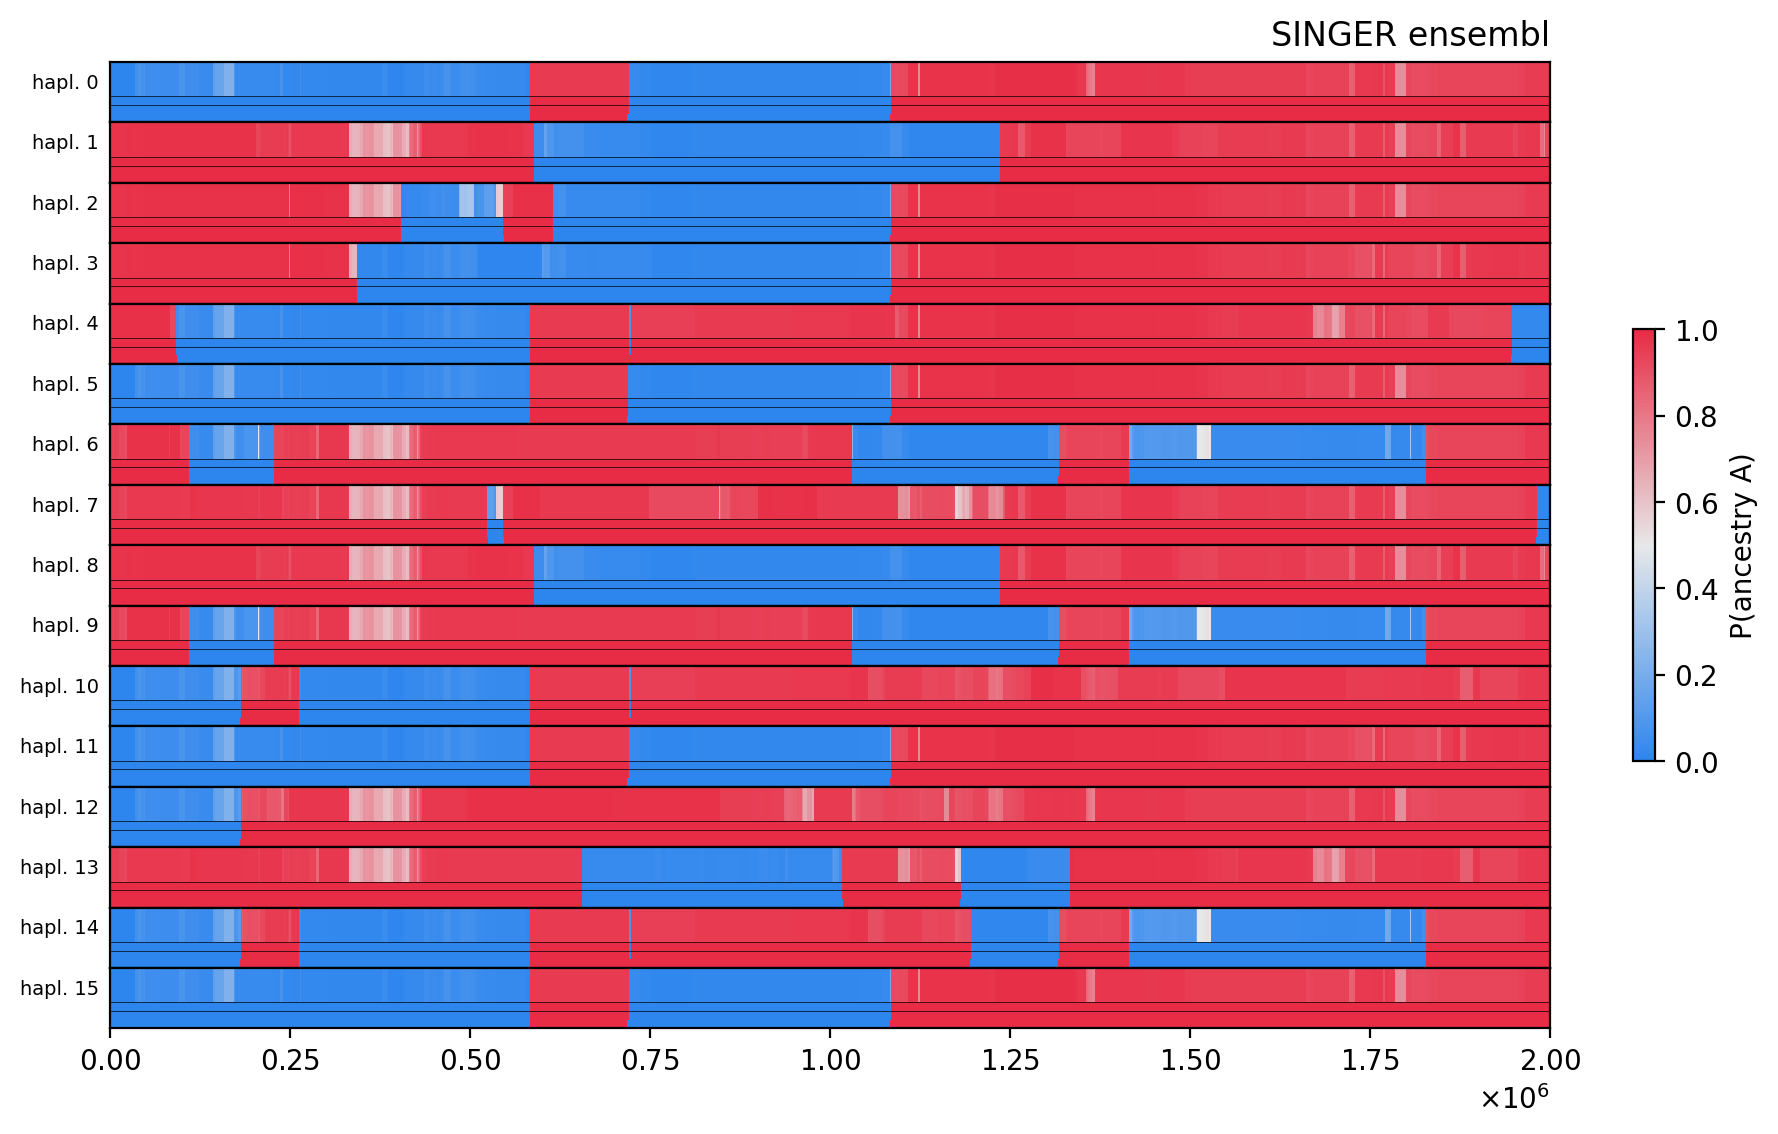

In [15]:
paint_singer_posterior.plot(truth=truth, title='SINGER ensembl', colors=[ '#2D85EE', "#E7E8E9", "#E82C45"])

## Dating / cross-color coalescence rate

In [16]:
rtt = paint_singer.rate_through_time(n_iter=10)     # reuses the painting's fit; posteriors untouched


`q_AB(t)` and `q_BA(t)` vs (backward) time on a log axis. The rise marks the divergence epoch; recent time carries ~no cross-ancestry rate. (Convention: a jump is parent→child = old→young = forward in time, so a *backward*-time A→B admixture shows in `q_BA`.)

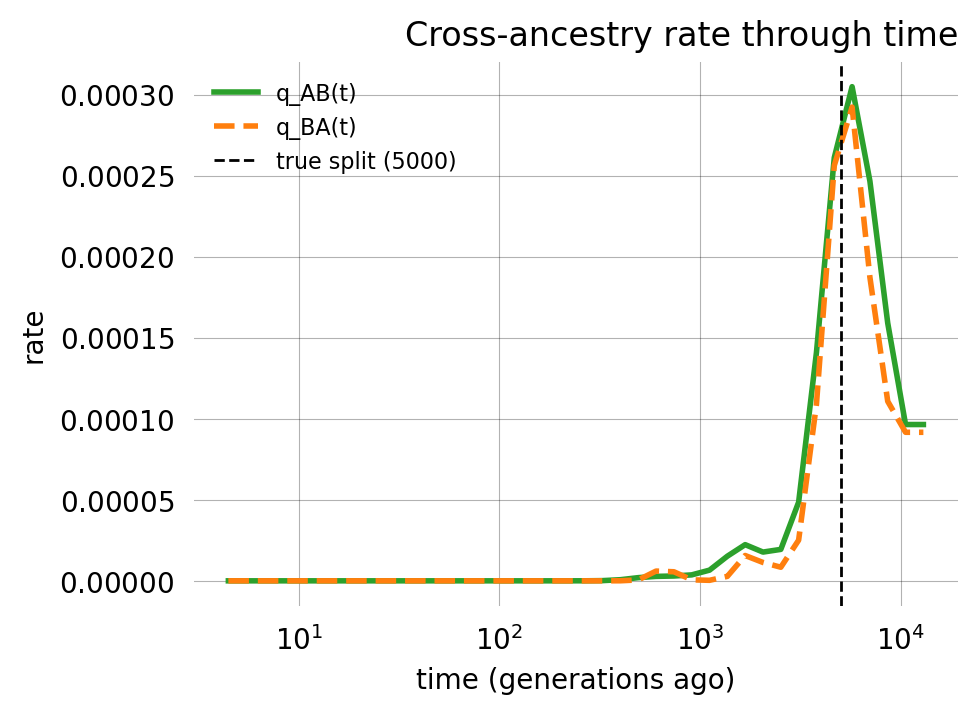

In [17]:
#| label: fig-dating-profile
#| fig-cap: "Directional cross-ancestry transition rates q_AB(t), q_BA(t) vs backward time: ~0 more recent than the population split, rising once cross-ancestry sharing becomes possible. The dashed line is the true split time."
fig, ax = plt.subplots()
rtt.plot(ax=ax)
ax.axvline(T_split, color="k", ls="--", lw=1, label=f"true split ({T_split})")
ax.set_title("Cross-ancestry rate through time")
ax.legend(fontsize=8)
fig.tight_layout()

The standalone entry point `tspaint.fit_rate_through_time(ts, labels)` does the same fit when the painting is not already available.

In [18]:
import numpy as np
onset = rtt.centers[np.argmax(rtt.q_AB > 0.5 * np.nanmax(rtt.q_AB))]
print(f"inferred onset ~ {onset:.0f} generations   (true split {T_split})")

inferred onset ~ 4654 generations   (true split 5000)


Use SINGER's posterior for a confidence estimate in dating:

In [19]:
er = paint_singer_posterior.rate_through_time()        # ensemble painting

ModuleNotFoundError: No module named 'tspaint.parallel'

In [ ]:
# point estimate (median over members), generations agoer.split_time_ci(level=0.95)             # (lo, hi) — the ARG-uncertainty band on the split
er.split_time()                            

3807.710098689057

In [ ]:
# er.split_times                           # (M,) per-member estimates
# er.members                               # the M RateThroughTime profiles
er.q_AB, er.q_BA, er.centers             # ensemble-mean rate profile

(array([7.75124571e-09, 8.06063672e-09, 8.32109100e-09, 8.57835525e-09,
        8.86702086e-09, 9.21947580e-09, 9.66186942e-09, 1.02218588e-08,
        1.09411968e-08, 1.18769989e-08, 1.31131555e-08, 1.47708983e-08,
        1.70257041e-08, 2.02841038e-08, 2.50165627e-08, 3.19990163e-08,
        4.27913814e-08, 6.04500017e-08, 8.56588617e-08, 1.07112127e-07,
        1.39120015e-07, 2.85598546e-07, 9.63325829e-07, 5.66862022e-07,
        1.91255155e-07, 2.60342111e-07, 8.85383055e-07, 3.32681041e-06,
        2.12872019e-06, 1.65982987e-06, 2.80283305e-06, 8.78906946e-06,
        4.91462213e-05, 2.19573102e-04, 3.33581050e-04, 2.71011884e-04,
        1.86981236e-04, 1.08472382e-04, 8.08468982e-05, 7.80235086e-05]),
 array([1.62419418e-08, 1.69760126e-08, 1.70688168e-08, 1.67618462e-08,
        1.61040357e-08, 1.50827857e-08, 1.37220922e-08, 1.20896968e-08,
        1.03065835e-08, 8.52321780e-09, 6.89044074e-09, 5.48733065e-09,
        4.39096741e-09, 3.59697761e-09, 3.11054523e-09, 2.9322

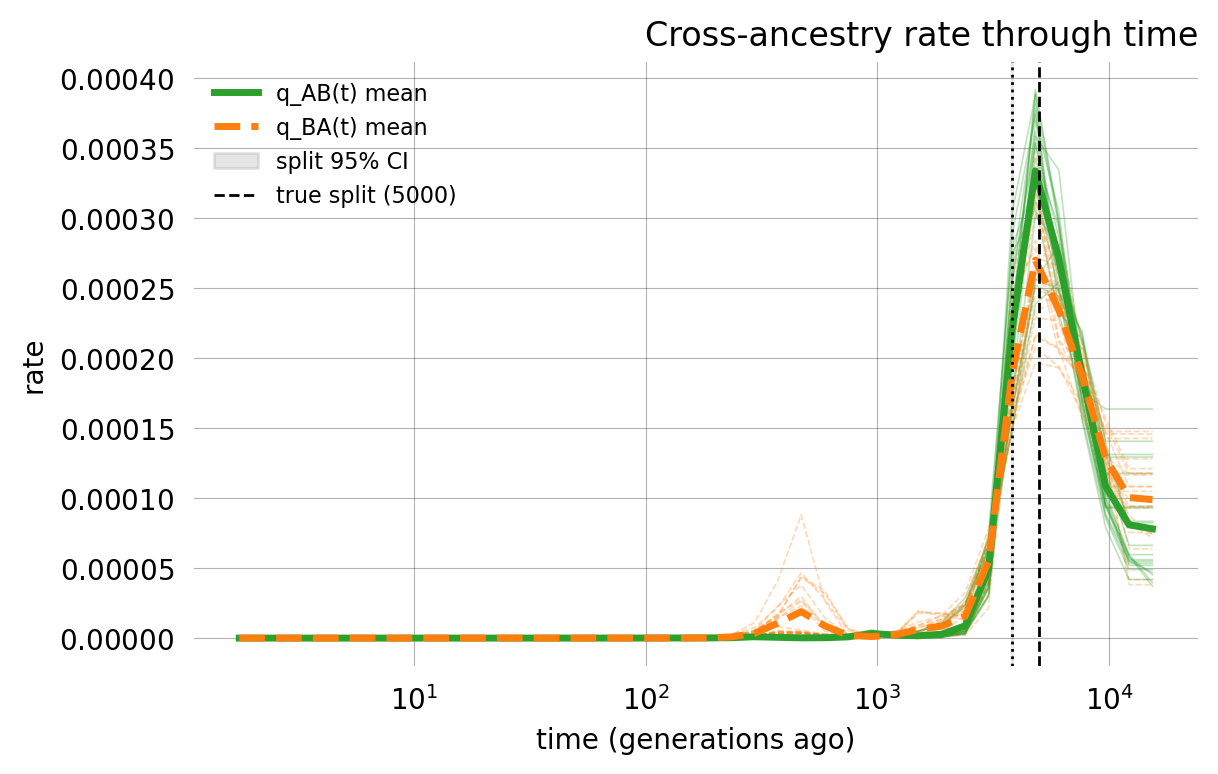

In [ ]:
fig, ax = plt.subplots(figsize=(6.2, 4))
er.plot(ax=ax)
ax.axvline(T_split, color="k", ls="--", lw=1, label=f"true split ({T_split})")
ax.set_title("Cross-ancestry rate through time")
ax.legend(fontsize=8)
fig.tight_layout()

In [ ]:

paint_singer.save("paint_singer.npz")
paint_tsinfer.save("paint_tsinfer.npz")
paint_singer_posterior.save("paint_singer_posterior.npz")


ModuleNotFoundError: No module named 'tspaint.serialize'

In [ ]:

p.save("painting.npz")
# back = tspaint.Painting.load("painting.npz")
# from tspaint import serialize
# serialize.save_ghost("ghost.npz", g);  serialize.load_ghost("ghost.npz")


In [29]:
qc = tspaint.reference_qc(ts_singer, labels)            # two-pass audit
qc.summary()                                     # per-ref credibility / foreign_fraction (least-credible first)


KeyboardInterrupt: 

In [ ]:
# 2. Task 1 — reference QC (control panel contamination)

qc = tspaint.reference_qc(ts, labels)            # two-pass audit
qc.summary()                                     # per-ref credibility / foreign_fraction (least-credible first)

# act on it — re-paint with the suspect references down-weighted:
clean = tspaint.paint(ts, labels, soft_refs=qc.soft_refs())
qc.mask()                                        # or: {ref: [(left,right), ...]} foreign spans to drop
qc.soft_refs(max_credibility=0.8)                # suspects below a credibility cutoff

#3. Task 2 — ghost / archaic introgression search (accurate, reference-free)

queries = [s for s in range(ts.num_samples) if s not in labels]

g = tspaint.detect_ghost(ts, labels, queries)            # depth-emission HMM -> GhostResult
g.posteriors[queries[0]]                                 # [(left, right, P(ghost)), ...] calibrated
g.tracts(queries[0], threshold=0.5)                      # hard ghost tracts
g.burden                                                 # per-sample genome-wide ghost burden

# accuracy from a SINGER ensemble (pooled fit, averaged P(ghost)):
g = tspaint.detect_ghost(ensemble, labels, queries)

# calibration-robust depth (use on Relate / miscalibrated branch lengths):
g = tspaint.detect_ghost(ts, labels, queries, depth="rank")

#4. Anonymous foreign tracts (+ the fast deep-ghost flag)

ft = tspaint.foreign_tracts(ts, labels, queries)                       # {sample: [(l, r, score)]}
flag = tspaint.foreign_tracts(ts, labels, queries,                      # fast deterministic deep flag
                            mode="fit", min_score=0.8, min_depth=0.9) # (replaces the old detect_ghost flag)

#5. Save / load (.npz)

p.save("painting.npz");  back = tspaint.Painting.load("painting.npz")
from tspaint import serialize
serialize.save_ghost("ghost.npz", g);  serialize.load_ghost("ghost.npz")

#6. CLI / GWF spine (file-in/file-out, --cores from $SLURM_JOB_CPUS_PER_NODE)

# tspaint simulate --n-admix 8 --n-ref 8 -o sim.trees --labels-out labels.json   # or your data
# tspaint fit   member_*.trees --labels labels.json -j 8 -o params.npz           # one pooled fit
# tspaint paint member_0.trees --params params.npz   -j 8 -o p0.npz              # per member
# tspaint merge p_*.npz -o merged.npz                                            # ensemble mean + band

# tspaint qc    member_0.trees --labels labels.json --soft-refs-out suspects.txt -o qc.npz
# tspaint paint member_0.trees --labels labels.json --soft-refs @suspects.txt -o clean.npz   # Task 1
# tspaint ghost member_*.trees --labels labels.json --depth rank -o ghost.npz                # Task 2 
# (ensemble)

# # large chromosome: SINGER per 5 Mb window, then stitch per member
# tspaint trees singer-window data.vcf --start 0 --end 5e6 --out-prefix arg_w0 --ne 1e4 --mut-rate 1.25e-8
# --recomb-rate 1e-8
# tspaint trees merge-arg --manifest windows.tsv --member 5 --python <interp-with-tszip> -o member_5.trees

## Audit the reference panel (reference QC)

Painting trusts the labels on the reference panel. Real panels are imperfect — some "reference" individuals are themselves admixed or mislabelled. `tspaint.reference_qc` audits the panel *from the genealogy*: it reads each reference's **leave-one-out**  osterior (what the rest of the tree says about it, ignoring its own label), ranks references by **credibility**, and maps each one's own foreign tracts. 

We simulate a panel where two nominal `A`/`B` sub-panels carry a 30% minority of foreign ancestry, mixed in with pure anchors.

In [23]:
ts_qc = tspaint.sim.simulate_admixture_impure_refs(
    n_admix=2, n_pure=8, n_impure=4, sequence_length=2e6,
    ref_impurity=0.3, Ne=1000, T_admix=150, T_split=5000, random_seed=3)
name_qc, pid_qc, of_qc = pops(ts_qc)
labels_qc = {s: 0 for s in of_qc("A") + of_qc("RA")}        # RA/RB: impure panels, nominally A/B
labels_qc.update({s: 1 for s in of_qc("B") + of_qc("RB")})
pure   = set(of_qc("A") + of_qc("B"))
impure = set(of_qc("RA") + of_qc("RB"))

qc = tspaint.reference_qc(ts_qc, labels_qc)
cred = qc.credibility
print(f"pure-anchor credibility  : mean {np.mean([cred[r] for r in pure]):.3f}")
print(f"impure-panel credibility : mean {np.mean([cred[r] for r in impure]):.3f}   "
      f"(lower = the genealogy disagrees with the label)")
print("\nleast-credible references (the audit surfaces the impure panels first):")
for row in qc.summary(deadband=0.3)[:6]:
    tag = "impure" if row["ref"] in impure else "pure  "
    print(f"  ref {row['ref']:>3} [{tag}]  label {row['label']}  "
          f"credibility {row['credibility']:.2f}  foreign_fraction {row['foreign_fraction']:.2f}")


pure-anchor credibility  : mean 0.938
impure-panel credibility : mean 0.705   (lower = the genealogy disagrees with the label)

least-credible references (the audit surfaces the impure panels first):
  ref  51 [impure]  label 1  credibility 0.20  foreign_fraction 0.91
  ref  39 [impure]  label 0  credibility 0.39  foreign_fraction 0.60
  ref  38 [impure]  label 0  credibility 0.45  foreign_fraction 0.58
  ref  48 [impure]  label 1  credibility 0.46  foreign_fraction 0.59
  ref  37 [impure]  label 0  credibility 0.55  foreign_fraction 0.38
  ref  36 [impure]  label 0  credibility 0.57  foreign_fraction 0.43


The impure references float to the top of the audit (lowest credibility). For any flagged reference, its **introgression map** — the leave-one-out posterior — recovers *where* on the genome it is foreign, which we can check against the census truth.

In [24]:
suspect = qc.summary(deadband=0.3)[0]["ref"]
lab = labels_qc[suspect]
flagged = qc.flagged_tracts(suspect, deadband=0.3)             # (left, right, foreign_state)
truth_qc, _ = tspaint.local_ancestry_truth(ts_qc)
s_of = {pid_qc["A"]: 0, pid_qc["B"]: 1}
true_foreign = [(l, r) for (l, r, p) in truth_qc[suspect] if s_of.get(p, lab) != lab]
print(f"suspect reference {suspect} (nominal label {lab}):")
print(f"  flagged foreign tracts : {[(round(l), round(r)) for l, r, _ in flagged]}")
print(f"  true foreign tracts    : {[(round(l), round(r)) for l, r in true_foreign]}")


suspect reference 51 (nominal label 1):
  flagged foreign tracts : [(83207, 1030583), (1121687, 2000000)]
  true foreign tracts    : [(83207, 2000000)]


The flagged span lands on the true foreign tract. The auto-bootstrap assumes the **clean references are the majority** (it picks the most self-consistent half as a trusted anchor core); when you already know which individuals are clean, pass them as  anchors=...`.

## Detect admixture from a source that is *not in the panel*

The hardest case: some of the admixture comes from a population you never sampled — an archaic "ghost". It cannot match any reference, but it also is not merely *ambiguous*: a ghost tract sits on an anomalously **deep** branch relative to every labelled reference. `tspaint.detect_ghost` keys on exactly that conjunction (fits no panel source **and** deep), so it separates a genuine unsampled source from an ordinary uninformative region.

We simulate admixed queries drawing 25% from an unsampled deep-outgroup ghost, plus a matched **no-ghost control**, and compare the genome-wide ghost **burden**.

In [25]:
def ghost_cohort(ghost_fraction, seed=1):
    ts = tspaint.sim.simulate_admixture_with_ghost(
        n_admix=12, n_ref=8, sequence_length=2e6, ghost_fraction=ghost_fraction,
        T_admix=100, T_split_AB=2000, T_split_ABC=20000, Ne=1000, random_seed=seed)
    nm, pd, of = pops(ts)
    q = of("ADMIX"); lab = {s: 0 for s in of("A")}; lab.update({s: 1 for s in of("B")})
    return ts, pd, q, lab

ts_g, pid_g, q_g, lab_g = ghost_cohort(0.25)
ts_c, pid_c, q_c, lab_c = ghost_cohort(0.00)        # matched no-ghost control
gh   = tspaint.detect_ghost(ts_g, lab_g, q_g)
ctrl = tspaint.detect_ghost(ts_c, lab_c, q_c)
b_ghost = float(np.mean([gh.burden[x]   for x in q_g]))
b_ctrl  = float(np.mean([ctrl.burden[x] for x in q_c]))
print(f"mean ghost burden  : 25% ghost cohort {b_ghost:.3f}   "
      f"no-ghost control {b_ctrl:.3f}   ({b_ghost / max(b_ctrl, 1e-6):.0f}x separation)")


mean ghost burden  : 25% ghost cohort 0.101   no-ghost control 0.010   (10x separation)


The burden separates the ghost cohort from the control roughly ten-fold — a clean genome-wide alarm. We can also localise it: shading one query's true ghost tracts (gray) and overlaying the detected ones (red).

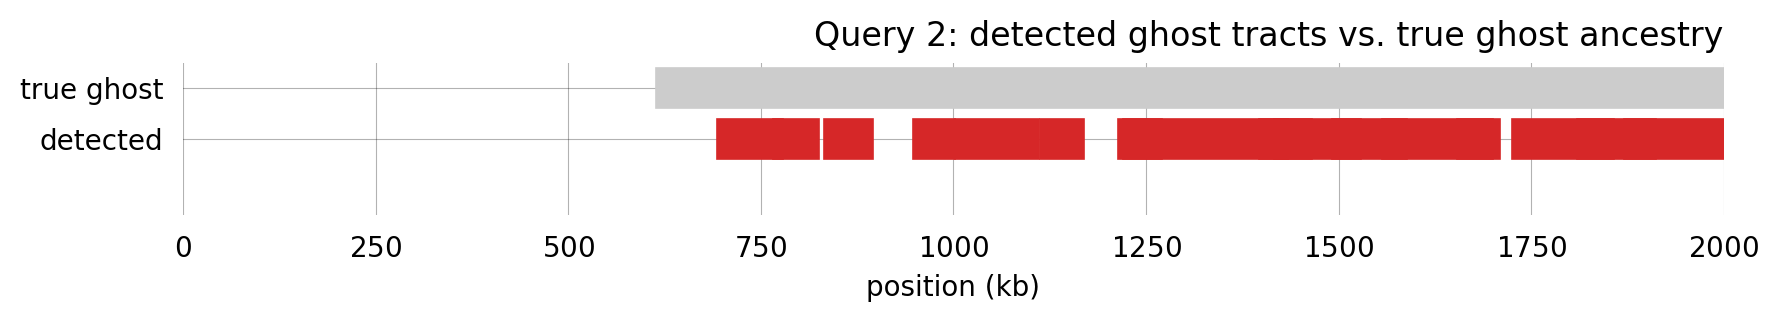

In [26]:
truth_g, _ = tspaint.local_ancestry_truth(ts_g)
GHOST = pid_g["GHOST"]
# show a query with a genuine mix of ghost and non-ghost ancestry (recall *and* specificity)
ghost_frac = lambda s: sum(r - l for (l, r, p) in truth_g[s] if p == GHOST) / ts_g.sequence_length
x = min(q_g, key=lambda s: abs(ghost_frac(s) - 0.5))
true_ghost = [(l, r) for (l, r, p) in truth_g[x] if p == GHOST]
det_ghost  = gh.tracts(x)
fig, ax = plt.subplots(figsize=(9, 1.7))
width = 0.25
for (l, r) in true_ghost:
    ax.plot([l / 1e3, r / 1e3], [2.5, 2.5], lw=15, color="0.8")
for (l, r) in det_ghost:
    ax.plot([l / 1e3, r / 1e3], [1.5, 1.5], lw=15, color="C3")

ax.set(xlim=(0, ts_g.sequence_length / 1e3), 
       ylim=(0, 3), 
       yticks=[1.5, 2.5],
       yticklabels=["detected", "true ghost"], 
       xlabel="position (kb)",
       title=f"Query {x}: detected ghost tracts vs. true ghost ancestry")
plt.tight_layout()

### With no reference at all: `detect_archaic`

`detect_ghost` still needs the `A`/`B` panel to define "deep". When you have **no archaic reference whatsoever**, `tspaint.detect_archaic` fits a genome-axis HMM on each haplotype's nearest-reference coalescence depth, *learning* the archaic state above the panel's deepest coalescence. It recovers the genome-wide burden more faithfully than the fixed-quantile flag above.

In [27]:
arch = tspaint.detect_archaic(ts_g, lab_g, q_g)
true_burden = float(np.mean([sum(r - l for (l, r, p) in truth_g[x] if p == GHOST)
                             / ts_g.sequence_length for x in q_g]))
print(f"true ghost burden            : {true_burden:.3f}")
print(f"detect_archaic (no ref)      : {np.mean([arch.burden[x] for x in q_g]):.3f}")
print(f"detect_ghost   (panel-deep)  : {b_ghost:.3f}")


true ghost burden            : 0.173
detect_archaic (no ref)      : 0.173
detect_ghost   (panel-deep)  : 0.101


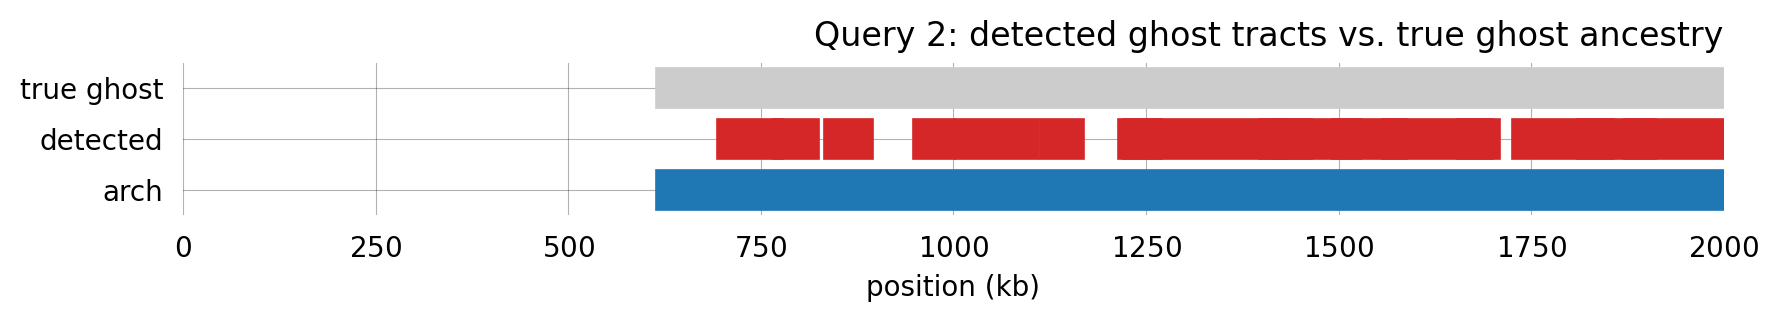

In [28]:
truth_g, _ = tspaint.local_ancestry_truth(ts_g)
GHOST = pid_g["GHOST"]
# show a query with a genuine mix of ghost and non-ghost ancestry (recall *and* specificity)
ghost_frac = lambda s: sum(r - l for (l, r, p) in truth_g[s] if p == GHOST) / ts_g.sequence_length
x = min(q_g, key=lambda s: abs(ghost_frac(s) - 0.5))
true_ghost = [(l, r) for (l, r, p) in truth_g[x] if p == GHOST]
det_ghost  = gh.tracts(x)
fig, ax = plt.subplots(figsize=(9, 1.7))
width = 0.25
for (l, r) in true_ghost:
    ax.plot([l / 1e3, r / 1e3], [2.5, 2.5], lw=15, color="0.8")
for (l, r) in det_ghost:
    ax.plot([l / 1e3, r / 1e3], [1.5, 1.5], lw=15, color="C3")

det_arch  = arch.tracts(x)
for (l, r) in det_arch:
    ax.plot([l / 1e3, r / 1e3], [0.5, 0.5], lw=15, color="C0")

ax.set(xlim=(0, ts_g.sequence_length / 1e3), 
       ylim=(0, 3), 
       yticks=[0.5, 1.5, 2.5],
       yticklabels=["arch", "detected", "true ghost"], 
       xlabel="position (kb)",
       title=f"Query {x}: detected ghost tracts vs. true ghost ancestry")
plt.tight_layout()

## Recap

One toolkit, one progression:

| Step | Call | What you get |
|------|------|--------------|
| Genotypes → ARG | `io.tsinfer` / `io.singer` (VCF / Zarr / ts) | a tspaint-ready tree sequence (or a posterior ensemble) |
| Paint & compare | `paint(ts, labels, smooth=True)` | calibrated soft `P(ancestry)` per haplotype per position |
| Quantify ARG uncertainty | `ensemble.merge_posterior_tables` | ensemble-mean painting **+ uncertainty band** |
| Trust the panel | `reference_qc` | per-reference credibility + introgression maps |
| Hidden source (panel-relative) | `detect_ghost` | foreign-to-panel tracts + genome-wide burden |
| Hidden source (reference-free) | `detect_archaic` | deep archaic tracts with no archaic reference |

The throughline is **calibration**: every output is a soft, honest posterior, so where the genealogy cannot decide you get `P ≈ 0.5` and a wide band rather than a confident mistake — and the same leave-one-out machinery that paints queries audits references and surfaces sources that are not in the panel at all.

**See also** — the focused notebooks: *painting* (accuracy vs. admixture age), *calibration* (reliability diagrams), *fragmentation* (the dead-band for tract-length / dating), *bp_smoother* (the §7 horizontal smoother), *dating* (admixture rate through time), and *introgression_qc* (the QC / ghost workflows in depth). Full signatures are in the [API reference](../api/).
